In [1]:
import joblib
import os
import pandas as pd
import numpy as np
from ratinabox.Environment import Environment
from ratinabox.Agent import Agent
from ratinabox.Neurons import PlaceCells, BoundaryVectorCells
import tqdm

In [2]:
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 1000)

In [3]:
def load_joblib_folder_as_df(folder_path, file_list=None):
    """
    Reads selected files (or all files if file_list is None) in a folder using joblib 
    and stores them in a dictionary as pandas DataFrames.

    Parameters:
    folder_path (str): Path to the folder containing joblib files.
    file_list (list, optional): List of filenames to load. Loads all files if None.

    Returns:
    dict: A dictionary where keys are filenames and values are pandas DataFrames.
    """
    loaded_data = {}
    
    # If no file list provided, read all files in the folder
    if file_list is None:
        file_list = os.listdir(folder_path)
    
    for file_name in file_list:
        file_path = os.path.join(folder_path, file_name)
        try:
            data = joblib.load(file_path)
            # Convert to DataFrame if not already
            if not isinstance(data, pd.DataFrame):
                data = pd.DataFrame(data)
            loaded_data[file_name] = data
            print(f"Loaded {file_name} successfully.")
        except Exception as e:
            print(f"Failed to load {file_name}: {e}")
    
    return loaded_data


In [4]:
data_path = '/Users/mariedelvalle/Documents/projects/neuro-rl/data-zenodo'
datasets = load_joblib_folder_as_df(data_path,['QLAK-CA1-08'])

Loaded QLAK-CA1-08 successfully.


In [5]:
datasets['QLAK-CA1-08']

,QLAK-CA1-08
SFPs,"[[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0. 0. 0. 0.], [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0. 0. 0. 0...."
blocked,"[[-1.0], [4.0], [[3.0, 5.0, 6.0, 8.0]], [[4.0, 5.0]], [[0.0, 3.0, 6.0]], [[0.0, 2.0, 6.0, 8.0]], [[3.0, 5.0]], [[1.0, 2.0, 4.0, 5.0]], [[0.0, 4.0]], [[0.0, 8.0]], [-1.0], [4.0], [[3.0, 5.0, 6.0, 8..."
centroids,"[[[123.17893512690762, 123.28645857824085, 123.3174549787598, 123.1464963500363, 123.41679324508634, 123.53073001197804, 123.56395410519856, 123.07087762596248, 123.24933948305697, 123.28687258478..."
envs,"[[square], [o], [t], [u], [rectangle], [+], [i], [l], [bit donut], [glenn], [square], [o], [t], [u], [rectangle], [+], [i], [l], [bit donut], [glenn], [square], [o], [t], [u], [rectangle], [+], [i..."
maps,{'sampling': [[[ 25.46666667 40.53333333 72.6 75.06666667 0. 0. 43.76666667 55.56666667 0. 0. 81.36666667 63.5 85.53333333 21.26666667 0. 0. ...
position,"[[[24.39408328226677, 24.39408328226677, 23.77486131643336, 22.934841108918263, 22.550760175690044, 21.764734603811334, 21.27432550782607, 20.921270210566483, 20.676744715347997, 20.58515622683701..."
trace,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0..."


In [6]:
Env = Environment()
Ag = Agent(Env)

In [7]:
behav_dict = joblib.load('/Users/mariedelvalle/Documents/projects/neuro-rl/data-zenodo/behav_dict')
behav_df = pd.DataFrame(behav_dict)
print(behav_df['QLAK-CA1-08']['position'][0,0,1])
print(behav_df['QLAK-CA1-08']['position'][0,1,1])
# Agent trajectory
# [0.2439408328226677, 0.19376940152439043]
# [0.23774861316433357, 0.19247431984734592]
# last [0.24394083297758737, 0.19376940158278178]
# behav_df

24.39408328226677
19.376940152439047


In [8]:
def deform_environment(Env, shape):
    """
    Deform environment geometry by inserting walls to riab environment as in Lee et al. (2025) study
    :param Env: riab environment to deform by addition of walls
    :param shape: shape of environment as a string (e.g., "glenn", "o", etc...).
    :return: None (Env object is modified in-place)
    """
    # Add walls to riab environment to deform geometry as per experiment
    if shape == 'glenn':
        Env.add_wall([[.25, 0], [.25, .25]])
        Env.add_wall([[.25, .25], [0, .25]])
        Env.add_wall([[.5, .5], [.5, .75]])
        Env.add_wall([[.5, .5], [.75, .5]])
    elif shape == 'o':
        Env.add_wall([[.25, .25], [.25, .5]])
        Env.add_wall([[.25, .5], [.5, .5]])
        Env.add_wall([[.5, .5], [.5, .25]])
        Env.add_wall([[.5, .25], [.25, .25]])
    elif shape == 'bit donut':
        Env.add_wall([[0., 0.25], [0.25, 0.25]])
        Env.add_wall([[0.25, 0.25], [0.25, 0]])
        Env.add_wall([[0.25, 0.25], [0.25, 0.5]])
        Env.add_wall([[0.25, 0.5], [0.5, 0.5]])
        Env.add_wall([[0.5, 0.5], [0.5, 0.25]])
        Env.add_wall([[0.5, .25], [0.25, 0.25]])
    elif shape == 'u':
        Env.add_wall([[.25, .25], [.75, .25]])
        Env.add_wall([[.25, .25], [.25, .5]])
        Env.add_wall([[.25, .5], [.75, .5]])
    elif shape == '+':
        Env.add_wall([[.25, 0.], [.25, .25]])
        Env.add_wall([[.25, .25], [0., .25]])
        Env.add_wall([[0., 0.5], [.25, .5]])
        Env.add_wall([[.25, .5], [.25, .75]])
        Env.add_wall([[.5, .5], [.5, .75]])
        Env.add_wall([[.5, .5], [.75, .5]])
        Env.add_wall([[.5, .25], [.75, .25]])
        Env.add_wall([[.5, .25], [.5, 0.]])
    elif shape == 't':
        Env.add_wall([[0.00, 0.25], [0.25, 0.25]])
        Env.add_wall([[0.25, 0.25], [0.25, 0.75]])
        Env.add_wall([[0.50, 0.75], [0.50, 0.25]])
        Env.add_wall([[0.50, 0.25], [0.75, 0.25]])
    elif shape == 'l':
        Env.add_wall([[0.25, 0.], [0.25, .5]])
        Env.add_wall([[0.25, .5], [0.75, .5]])
    elif shape == 'i':
        Env.add_wall([[.25, .25], [0., .25]])
        Env.add_wall([[.25, .25], [.25, .5]])
        Env.add_wall([[.25, .5], [0., .5]])
        Env.add_wall([[.5, .25], [.75, .25]])
        Env.add_wall([[.5, .25], [.5, .5]])
        Env.add_wall([[.5, .5], [.75, .5]])
    elif shape == 'rectangle':
        Env.add_wall([[.25, .0], [0.25, .75]])

In [9]:
def build_riab_objects_for_animal(
    animal_data,
    day_idx=0,
    n_features=200,
    field_width=0.15,
    env_size=75,
    fps=30,
    random_seed=0
):
    """
    Build RatInABox Environment, Agent, PlaceCells, and BoundaryVectorCells
    for a given animal and day.

    Parameters
    ----------
    animal_data : dict
        behav_dict[animal]
    day_idx : int
        Which day/environment to build (default: 0)
    n_features : int
        Number of neurons
    field_width : float
        Place field width (meters)
    env_size : float
        Environment size in cm
    fps : int
        Frames per second
    random_seed : int
        Random seed for reproducibility

    Returns
    -------
    Env : ratinabox.Environment
    Ag : ratinabox.Agent
    PC : ratinabox.PlaceCells
    BVC : ratinabox.BoundaryVectorCells
    """

    # --- Position (same scaling as simulate_bases)
    position = env_size * 0.01 * (
        animal_data["position"] / animal_data["position"].max()
    )

    env_name = animal_data["envs"][day_idx]

    # --- Environment
    Env = Environment(
        params={
            "aspect": 1,
            "scale": 0.75,
            "dimensionality": "2D",
        }
    )

    # Apply geometry deformation
    deform_environment(Env, env_name)

    # --- Agent
    Ag = Agent(Env, params={"dt": 1 / fps})

    # --- Import trajectory
    Ag.import_trajectory(
        times=[i / fps for i in range(position.shape[-1])],
        positions=position[day_idx].T,
        interpolate=False,
    )

    for key in list(Ag.history.keys()):
        Ag.history[key] = [0]

    # --- Place Cells
    np.random.seed(random_seed)
    PC = PlaceCells(
        Ag,
        params={
            "n": n_features,
            "description": "gaussian_threshold",
            "widths": field_width,
            "wall_geometry": "euclidean",
            "min_fr": 0,
            "max_fr": 1,
            "color": "C2",
        },
    )

    # --- Boundary Vector Cells (allocentric)
    np.random.seed(random_seed)
    BVC = BoundaryVectorCells(
        Ag,
        params={
            "n": n_features,
            "reference_frame": "allocentric",
            "tuning_distance_distribution": "uniform",
            "tuning_distance": (0, 0.85),
            "tuning_angle_distribution": "uniform",
            "sigma_distance": (0.08, 12),
            "sigma_angle": (11.25, 11.25),
            "sigma_angle_distribution": "uniform",
            "dtheta": 2,
            "min_fr": 0,
            "max_fr": 1,
            "name": "BoundaryVectorCells",
            "color": "C2",
        },
    )

    T = position.shape[-1]
    # update first time step with actual data
    for i in range(int(1)):
        Ag.update()
    # then drop the zeros that was initialized with
    for key in list(Ag.history.keys()):
        Ag.history[key] = Ag.history[key][1:]
    # proceed with actual updates for entire session
    # Simulate
    for _ in range(1, int(T)):
        Ag.update()
        PC.update()
        BVC.update()
        

    return Env, Ag, PC, BVC


In [1]:
Env, Ag, PC, BVC = build_riab_objects_for_animal(behav_dict['QLAK-CA1-08'], day_idx=0)

NameError: name 'build_riab_objects_for_animal' is not defined

    • To AUTOMATICALLY save all plots (recommended), set  `ratinabox.autosave_plots = True`
    • To MANUALLY save plots, call                        `ratinabox.utils.save_figure(figure_object, save_title).
      This warning will not be shown again
HINT: You can stylize plots to make them look like repo/paper by calling `ratinabox.stylize_plots()`
      This hint will not be shown again


(<Figure size 187.5x187.5 with 1 Axes>, <Axes: >)

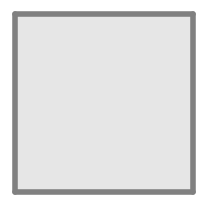

In [10]:
Env.plot_environment()

In [11]:
pd.DataFrame(Ag.history)

,t,pos,distance_travelled,vel,rot_vel,head_direction
0,0.033333,"[0.2439408328226677, 0.19376940152439043]",0.000544,"[0.0, 0.01630642303824814]",40.388417,"[0.8867190176121581, 0.46230875376195196]"
1,0.066667,"[0.23774861316433357, 0.19247431984734592]",0.006870,"[-0.18576658975002408, -0.03885245031133522]",53.311003,"[0.8326105616454919, 0.5538588742959514]"
2,0.100000,"[0.2293484110891826, 0.19289697367030614]",0.015281,"[-0.25200606225452893, 0.012679614688806684]",-7.693449,"[0.6936982124360629, 0.7202657773787472]"
3,0.133333,"[0.22550760175690043, 0.19290744797060733]",0.019121,"[-0.11522427996846524, 0.0003142290090354938]",1.426362,"[0.49245774378899954, 0.8703363548549768]"
4,0.166667,"[0.21764734603811334, 0.19375936372286956]",0.027028,"[-0.23580767156361288, 0.025557472567867]",-3.157038,"[0.22532713848373745, 0.9742831624649636]"
...,...,...,...,...,...,...
71861,2395.400000,"[0.7368547149212629, 0.021879770225508445]",187.664473,"[-0.022644050048726827, 0.007617065495093035]",11.209220,"[0.9328252507898499, 0.360329087764024]"
71862,2395.433333,"[0.7363731144696462, 0.02251972285323862]",187.665274,"[-0.014448013548501448, 0.01919857883190528]",-18.035658,"[0.7910050380639099, 0.61180963522775]"
71863,2395.466667,"[0.7361368840665549, 0.023091542296614954]",187.665893,"[-0.007086912092738595, 0.01715458330129]",-7.601577,"[0.614319728580603, 0.7890572039317899]"
71864,2395.500000,"[0.7361046007741162, 0.023262659427416964]",187.666067,"[-0.0009684987731595207, 0.0051335139240603]",-6.163018,"[0.4646366301617895, 0.8855014409428685]"


(<Figure size 187.5x187.5 with 1 Axes>, <Axes: >)

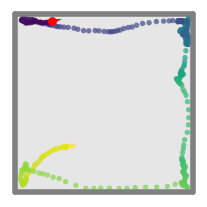

In [12]:
Ag.plot_trajectory(t_start=0,t_end=50,color="changing")

(<Figure size 562.5x187.5 with 6 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

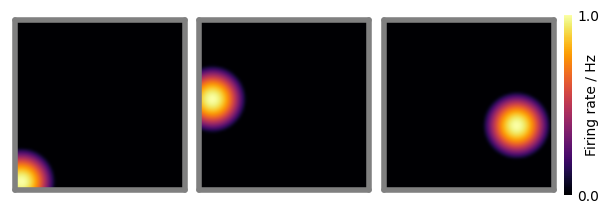

In [14]:
PC.plot_rate_map(chosen_neurons="3", method="groundtruth")